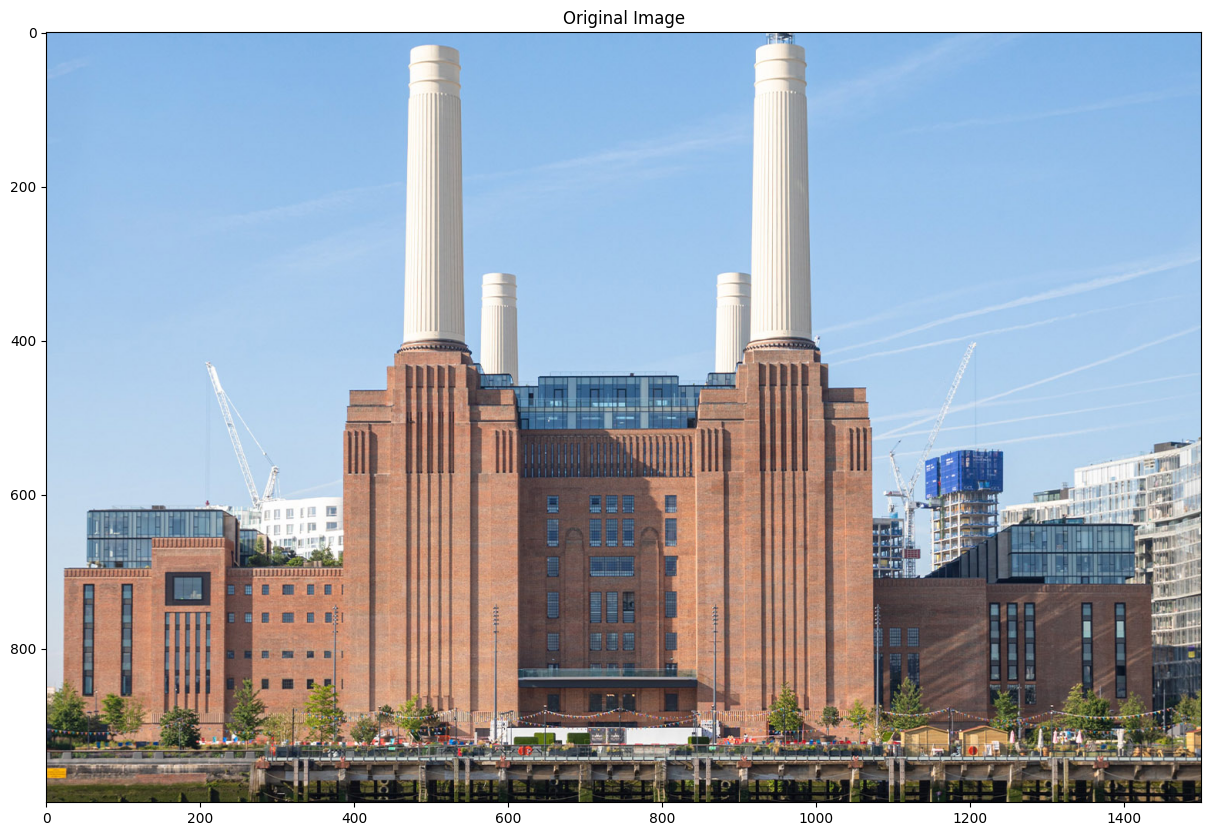

Quantizing Image: 100%|██████████| 1000/1000 [00:04<00:00, 209.55it/s]


Average Quantization Error: 58.27


Applying Dithering: 100%|██████████| 1000/1000 [00:18<00:00, 54.46it/s]


Average Dithering Error: 68.81


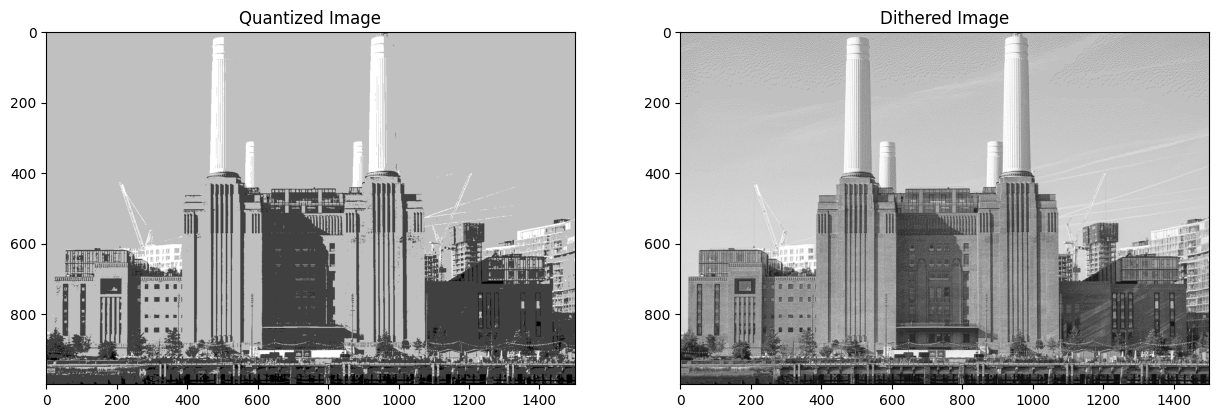

In [18]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

plt.rcParams["figure.figsize"] = [15, 10]

sourceImagePath = "../../data/lesson_5/Battersea-Power-Station.jpg"
img = cv2.imread(sourceImagePath)

if img is None:
    raise FileNotFoundError(f"Image not found at {sourceImagePath}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Original Image")
plt.show()

colors = np.array([[0, 0, 0], [64, 64, 64], [192, 192, 192], [255, 255, 255]])

img_float = img.astype(np.float32)

rows, cols, channels = img.shape
quantized_img = np.zeros_like(img_float)

for r in tqdm(range(rows), desc="Quantizing Image"):
    for c in range(cols):
        pixel = img_float[r, c]
        distances = np.linalg.norm(colors - pixel, axis=1)
        closest_color_index = np.argmin(distances)
        new_pixel = colors[closest_color_index]
        quantized_img[r, c, :] = new_pixel

avg_quant_error = np.mean(np.linalg.norm(img_float - quantized_img, axis=2))
print(f"Average Quantization Error: {avg_quant_error:.2f}")

img_temp = np.copy(img_float)
dithering_img = np.zeros_like(img_float)

for r in tqdm(range(rows), desc="Applying Dithering"):
    for c in range(cols):
        pixel = img_temp[r, c]
        distances = np.linalg.norm(colors - pixel, axis=1)
        closest_color_index = np.argmin(distances)
        new_pixel = colors[closest_color_index]

        quant_error = pixel - new_pixel

        if c + 1 < cols:
            img_temp[r, c + 1] += quant_error * 7 / 16
        if r + 1 < rows and c > 0:
            img_temp[r + 1, c - 1] += quant_error * 3 / 16
        if r + 1 < rows:
            img_temp[r + 1, c] += quant_error * 5 / 16
        if r + 1 < rows and c + 1 < cols:
            img_temp[r + 1, c + 1] += quant_error * 1 / 16

        dithering_img[r, c] = new_pixel

avg_dith_error = np.mean(np.linalg.norm(img_float - dithering_img, axis=2))
print(f"Average Dithering Error: {avg_dith_error:.2f}")

plt.subplot(121)
plt.imshow(quantized_img.astype(np.uint8))   # optimally quantized
plt.title("Quantized Image")
plt.subplot(122)
plt.imshow(dithering_img.astype(np.uint8))   # dithering
plt.title("Dithered Image")
plt.show()


"Which image has higher quantization error? Optimally quantized or dithered?"
> Изображение с квантованием по Floyd-Steinberg Dithering имеет более высокую ошибку квантования, потому что мы собственно добавили шум из-за чего ошибка и увеличилась. Но с точки зрения визуального восприятия, изображение выглядит намного лучше и ближе к оригиналу

"Which image looks better to you?"
> Мне больше нравится изображение с квантованием по Floyd-Steinberg Dithering как и описал выше, но я понимаю что с математической точки зрения обычное квантование ближе к оригиналу :)

"Can you repeat the same process using only two colours: black and white? Show me :-)"
> Попробую :)
> Попробовал, очень удивился результату, обычная квантованная картинка выглядит хуже, как я и ожидал, а вот с Floyd-Steinberg Dithering получилось очень неожиданно, ошибка выросла и стала 172, но визуально картинка если не лучше то где-то так же как и в первом варианте с 4мя цветами, просто за счет шума и подобраных коефициентов ошибки, очень круто!

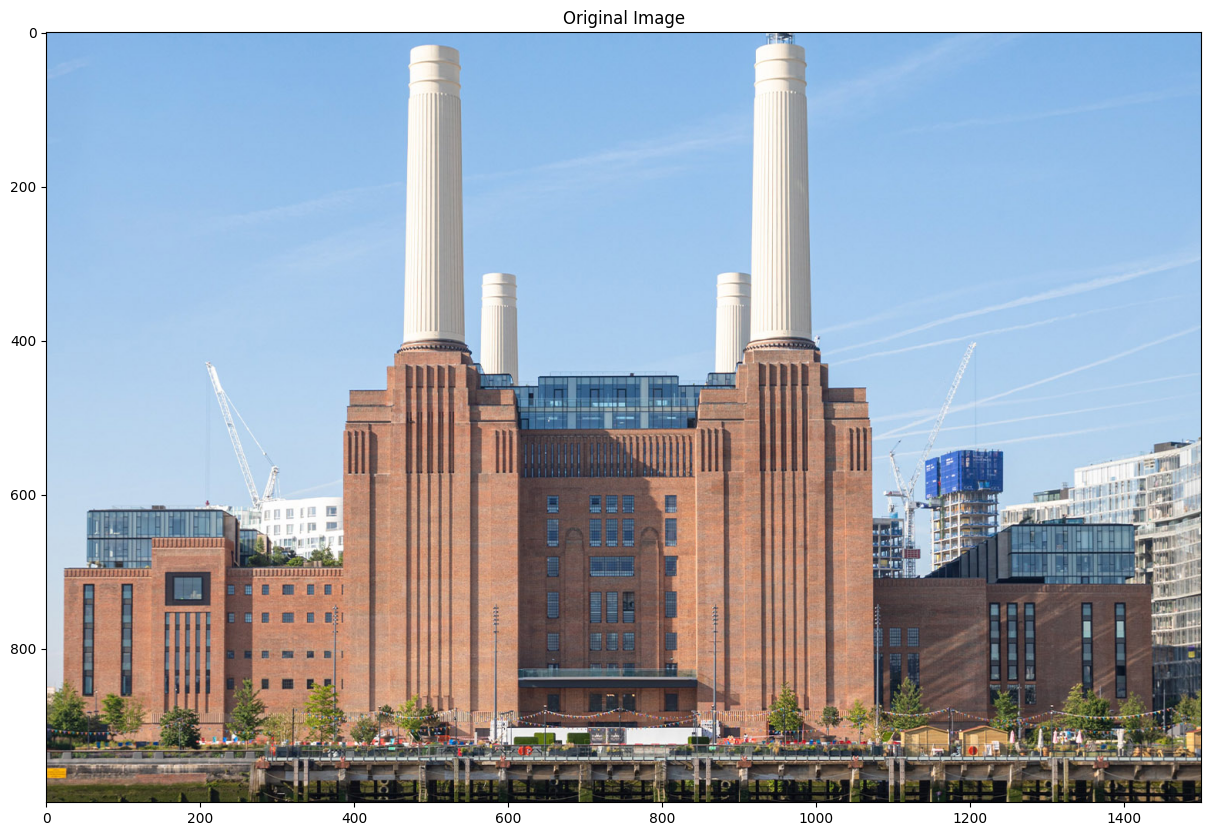

Quantizing Image: 100%|██████████| 1000/1000 [00:04<00:00, 207.91it/s]


Average Quantization Error: 129.46


Applying Dithering: 100%|██████████| 1000/1000 [00:18<00:00, 54.23it/s]


Average Dithering Error: 172.78


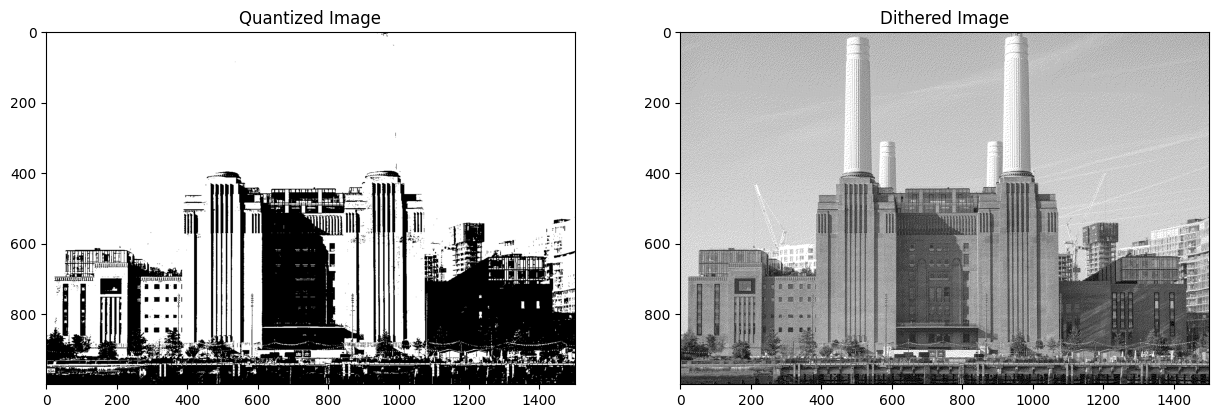

In [19]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

plt.rcParams["figure.figsize"] = [15, 10]

sourceImagePath = "../../data/lesson_5/Battersea-Power-Station.jpg"
img = cv2.imread(sourceImagePath)

if img is None:
    raise FileNotFoundError(f"Image not found at {sourceImagePath}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Original Image")
plt.show()

colors = np.array([[0, 0, 0], [255, 255, 255]])

img_float = img.astype(np.float32)

rows, cols, channels = img.shape
quantized_img = np.zeros_like(img_float)

for r in tqdm(range(rows), desc="Quantizing Image"):
    for c in range(cols):
        pixel = img_float[r, c]
        distances = np.linalg.norm(colors - pixel, axis=1)
        closest_color_index = np.argmin(distances)
        new_pixel = colors[closest_color_index]
        quantized_img[r, c, :] = new_pixel

avg_quant_error = np.mean(np.linalg.norm(img_float - quantized_img, axis=2))
print(f"Average Quantization Error: {avg_quant_error:.2f}")

img_temp = np.copy(img_float)
dithering_img = np.zeros_like(img_float)

for r in tqdm(range(rows), desc="Applying Dithering"):
    for c in range(cols):
        pixel = img_temp[r, c]
        distances = np.linalg.norm(colors - pixel, axis=1)
        closest_color_index = np.argmin(distances)
        new_pixel = colors[closest_color_index]

        quant_error = pixel - new_pixel

        if c + 1 < cols:
            img_temp[r, c + 1] += quant_error * 7 / 16
        if r + 1 < rows and c > 0:
            img_temp[r + 1, c - 1] += quant_error * 3 / 16
        if r + 1 < rows:
            img_temp[r + 1, c] += quant_error * 5 / 16
        if r + 1 < rows and c + 1 < cols:
            img_temp[r + 1, c + 1] += quant_error * 1 / 16

        dithering_img[r, c] = new_pixel

avg_dith_error = np.mean(np.linalg.norm(img_float - dithering_img, axis=2))
print(f"Average Dithering Error: {avg_dith_error:.2f}")

plt.subplot(121)
plt.imshow(quantized_img.astype(np.uint8))   # optimally quantized
plt.title("Quantized Image")
plt.subplot(122)
plt.imshow(dithering_img.astype(np.uint8))   # dithering
plt.title("Dithered Image")
plt.show()


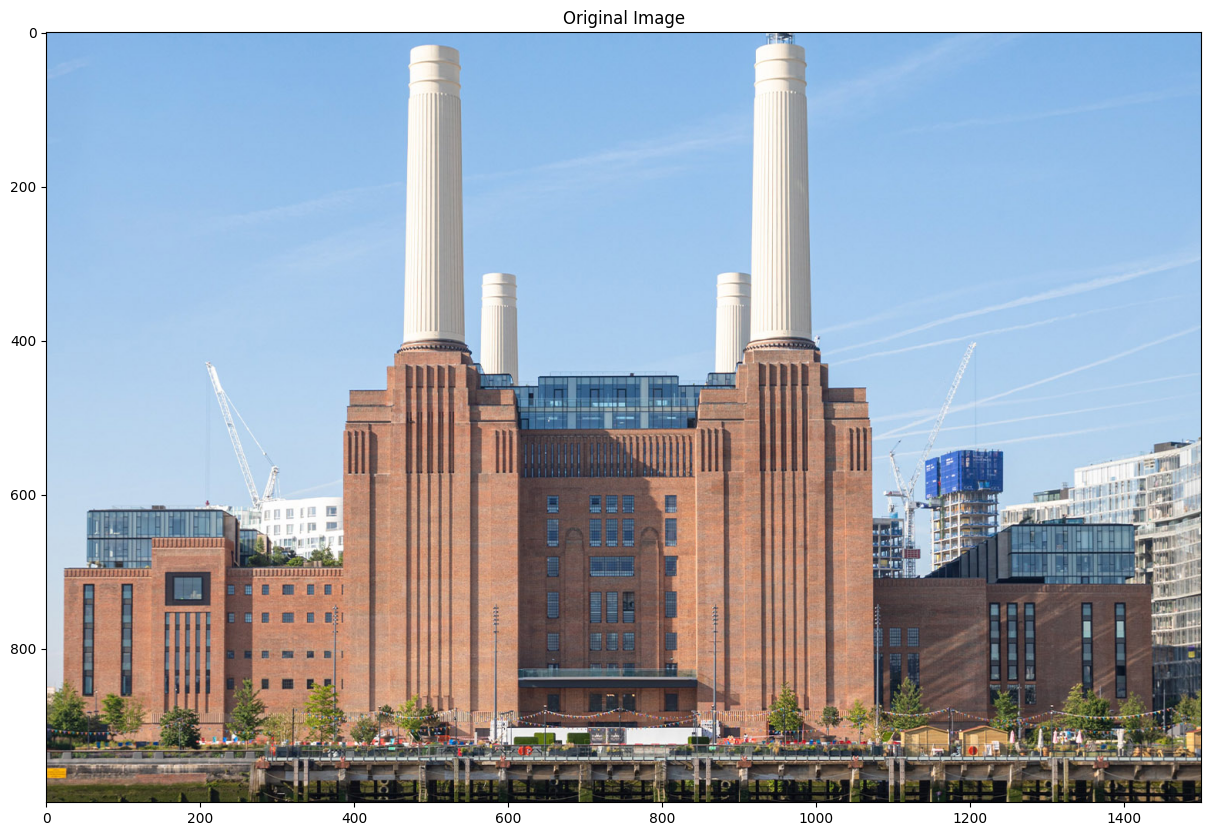

Quantizing Image: 100%|██████████| 1000/1000 [00:08<00:00, 119.63it/s]


Average Quantization Error: 3.90


Applying Dithering: 100%|██████████| 1000/1000 [00:21<00:00, 45.85it/s]


Average Dithering Error: 5.95


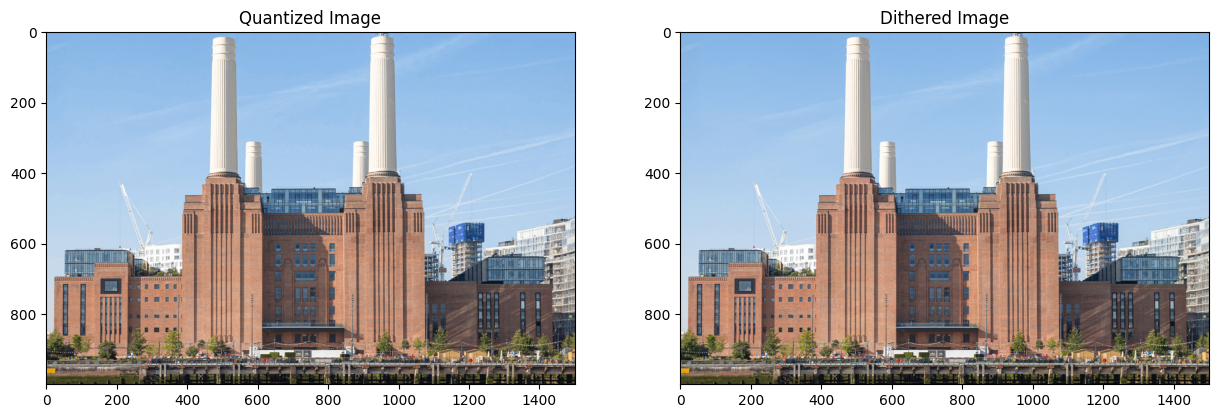

In [24]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
from sklearn.cluster import KMeans

plt.rcParams["figure.figsize"] = [15, 10]

sourceImagePath = "../../data/lesson_5/Battersea-Power-Station.jpg"
img = cv2.imread(sourceImagePath)

if img is None:
    raise FileNotFoundError(f"Image not found at {sourceImagePath}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Original Image")
plt.show()

kmeans = KMeans(n_clusters=256).fit(np.reshape(img, (-1, 3)))
colors = kmeans.cluster_centers_

img_float = img.astype(np.float32)

rows, cols, channels = img.shape
quantized_img = np.zeros_like(img_float)

for r in tqdm(range(rows), desc="Quantizing Image"):
    for c in range(cols):
        pixel = img_float[r, c]
        distances = np.linalg.norm(colors - pixel, axis=1)
        closest_color_index = np.argmin(distances)
        new_pixel = colors[closest_color_index]
        quantized_img[r, c, :] = new_pixel

avg_quant_error = np.mean(np.linalg.norm(img_float - quantized_img, axis=2))
print(f"Average Quantization Error: {avg_quant_error:.2f}")

img_temp = np.copy(img_float)
dithering_img = np.zeros_like(img_float)

for r in tqdm(range(rows), desc="Applying Dithering"):
    for c in range(cols):
        pixel = img_temp[r, c]
        distances = np.linalg.norm(colors - pixel, axis=1)
        closest_color_index = np.argmin(distances)
        new_pixel = colors[closest_color_index]

        quant_error = pixel - new_pixel

        if c + 1 < cols:
            img_temp[r, c + 1] += quant_error * 7 / 16
        if r + 1 < rows and c > 0:
            img_temp[r + 1, c - 1] += quant_error * 3 / 16
        if r + 1 < rows:
            img_temp[r + 1, c] += quant_error * 5 / 16
        if r + 1 < rows and c + 1 < cols:
            img_temp[r + 1, c + 1] += quant_error * 1 / 16

        dithering_img[r, c] = new_pixel

avg_dith_error = np.mean(np.linalg.norm(img_float - dithering_img, axis=2))
print(f"Average Dithering Error: {avg_dith_error:.2f}")

plt.subplot(121)
plt.imshow(quantized_img.astype(np.uint8))   # optimally quantized
plt.title("Quantized Image")
plt.subplot(122)
plt.imshow(dithering_img.astype(np.uint8))   # dithering
plt.title("Dithered Image")
plt.show()


Задание на Bonus Points:
Сделал квантование с подбором цветовой схемы с помощью KMeans

На 16 цветов результат:
```
Quantizing Image: 100%|██████████| 1000/1000 [00:04<00:00, 202.71it/s]
Average Quantization Error: 12.44
Applying Dithering: 100%|██████████| 1000/1000 [00:18<00:00, 54.78it/s]
Average Dithering Error: 19.45
```
Есть градиент при квантовании как когда-то на приставке 16 бит. При квантовании по Floyd-Steinberg Dithering градиента нет благодаря шуму.

На 32 цвета результат:
```
Quantizing Image: 100%|██████████| 1000/1000 [00:05<00:00, 199.26it/s]
Average Quantization Error: 8.84
Applying Dithering: 100%|██████████| 1000/1000 [00:18<00:00, 54.42it/s]
Average Dithering Error: 13.77
```
Градиент меньше, но все равно заметен, а при квантовании по Floyd-Steinberg Dithering градиента по прежнему нет :)

На 256 цветов результат:
```
Quantizing Image: 100%|██████████| 1000/1000 [00:08<00:00, 119.63it/s]
Average Quantization Error: 3.90
Applying Dithering: 100%|██████████| 1000/1000 [00:21<00:00, 45.85it/s]
Average Dithering Error: 5.95
```
Градиента уже нет, ошибка минимальная, скорость обработки так же замедлилась, на мой взгляд, оптимальное количество цветов для этого изображения 16-32 цветов. Дальше разницу визуально не видно, но скорость значительно падает.